In [1]:
# 1. IMPORT LIBRARIES
# =====================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 2. LOAD DATASET
# =====================================================

df = pd.read_csv("CVD_cleaned.csv")

print("Original Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())

Original Shape: (308854, 19)

First 5 Rows:
   General_Health                  Checkup Exercise Heart_Disease Skin_Cancer  \
0           Poor  Within the past 2 years       No            No          No   
1      Very Good     Within the past year       No           Yes          No   
2      Very Good     Within the past year      Yes            No          No   
3           Poor     Within the past year      Yes           Yes          No   
4           Good     Within the past year       No            No          No   

  Other_Cancer Depression Diabetes Arthritis     Sex Age_Category  \
0           No         No       No       Yes  Female        70-74   
1           No         No      Yes        No  Female        70-74   
2           No         No      Yes        No  Female        60-64   
3           No         No      Yes        No    Male        75-79   
4           No         No       No        No    Male          80+   

   Height_(cm)  Weight_(kg)    BMI Smoking_History  Alcohol

In [3]:
# 3. REMOVE DUPLICATE ROWS
# =====================================================

print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape After Removing Duplicates:", df.shape)


Duplicate Rows: 80
Shape After Removing Duplicates: (308774, 19)


In [4]:
# 4. CHECK MISSING VALUES
# =====================================================

print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64


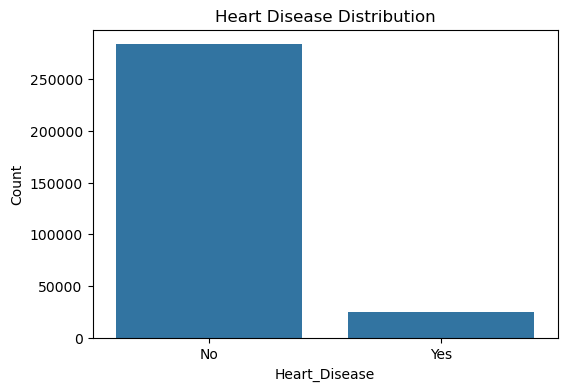

In [5]:
# 5. TARGET VARIABLE DISTRIBUTION (EDA)
# =====================================================

plt.figure(figsize=(6,4))
sns.countplot(x='Heart_Disease', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart_Disease")
plt.ylabel("Count")
plt.show()

In [6]:
# 6. SEPARATE FEATURES (X) AND TARGET (y)
# =====================================================

y = df['Heart_Disease']              # Target variable
X = df.drop('Heart_Disease', axis=1) # Features

In [7]:
# 7. ENCODE CATEGORICAL FEATURES (ONLY X)
# =====================================================

X = pd.get_dummies(X, drop_first=True)

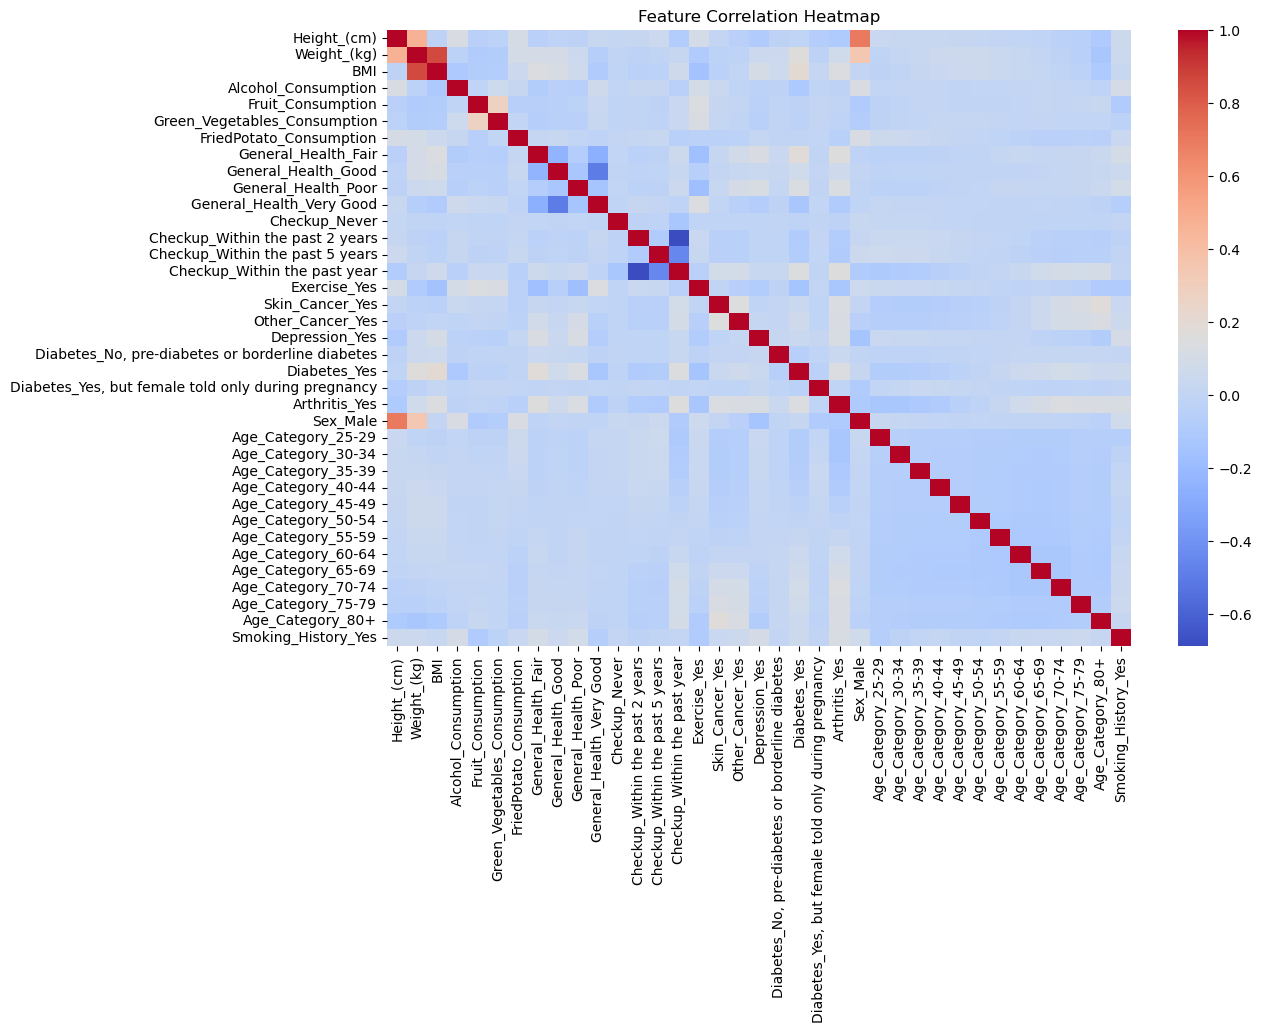

In [8]:
# 8. CORRELATION HEATMAP (EDA)
# =====================================================

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
# 9. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# 10. FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# 11. LOGISTIC REGRESSION MODEL
# =====================================================

model = LogisticRegression(max_iter=1000)  # increased iterations for stability

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [12]:
# 12. MODEL EVALUATION
# =====================================================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9187110355436807

Confusion Matrix:
 [[56423   254]
 [ 4766   312]]

Classification Report:
               precision    recall  f1-score   support

          No       0.92      1.00      0.96     56677
         Yes       0.55      0.06      0.11      5078

    accuracy                           0.92     61755
   macro avg       0.74      0.53      0.53     61755
weighted avg       0.89      0.92      0.89     61755

